In [ ]:
#Import và khai báo đường dẫn
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import files
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

DATASET_DIR = "/content/drive/MyDrive/Colab Notebooks/Ảnh selfie cho chiều t2 18 5"
IMG_SIZE = 200
BATCH_SIZE = 16
EPOCHS = 30
MODEL_PATH = "/content/face_cnn_model.h5"
LABELS_PATH = "/content/face_labels.json"

#Load ảnh và tăng dữ liệu
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest")

train_data = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training")

val_data = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation")

num_classes = train_data.num_classes
print("Số người cần nhận diện:", num_classes)
print("Tên class:", train_data.class_indices)

#Tạo CNN model
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"])

model.summary()

#Train và xem độ chính xác
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS)
loss, accuracy = model.evaluate(val_data)
print(f"Độ chính xác validation: {accuracy * 100:.2f}%")

#Lưu model CNN và tên người
model.save(MODEL_PATH)

index_to_class = {v: k for k, v in train_data.class_indices.items()}

with open(LABELS_PATH, "w", encoding="utf-8") as f:
    json.dump(index_to_class, f, ensure_ascii=False, indent=4)

print("Đã lưu model:", MODEL_PATH)
print("Đã lưu labels:", LABELS_PATH)


Found 290 images belonging to 8 classes.
Found 72 images belonging to 8 classes.
Số người cần nhận diện: 8
Tên class: {'AI': 0, 'Lê Quang Trường': 1, 'Phan Minh Thiện ': 2, 'QUÁCH BẢO VÂN': 3, 'Trần Nhật Nam': 4, 'my drivve': 5, 'Đặng Minh Khoa': 6, 'Đặng Ngọc Yến Nhi': 7}


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,761,544 (33.42 MB)

 Trainable params: 8,761,544 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 421ms/step - accuracy: 0.3103 - loss: 1.7607 - val_accuracy: 0.8194 - val_loss: 0.9297
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 357ms/step - accuracy: 0.7793 - loss: 0.6602 - val_accuracy: 0.8472 - val_loss: 0.5947
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 266ms/step - accuracy: 0.8655 - loss: 0.4370 - val_accuracy: 0.8472 - val_loss: 0.5263
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 287ms/step - accuracy: 0.9138 - loss: 0.3386 - val_accuracy: 0.8889 - val_loss: 0.2422
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 319ms/step - accuracy: 0.9414 - loss: 0.1756 - val_accuracy: 0.8889 - val_loss: 0.3879
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 259ms/step - accuracy: 0.9345 - loss: 0.1740 - val_accuracy: 0.9167 - val_loss: 0.3242
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 347ms/step - accuracy: 0.9517 - loss: 0.1559 - val_accuracy: 0.8889 - val_loss: 0.3819
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 262ms/step - accuracy: 0.9724 - loss: 0.1598 - val_accuracy: 0

Độ chính xác validation: 88.89%
Đã lưu model: /content/face_cnn_model.h5
Đã lưu labels: /content/face_labels.json


Saving IMG_20260518_081748_copy_200x200.jpg to IMG_20260518_081748_copy_200x200.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step


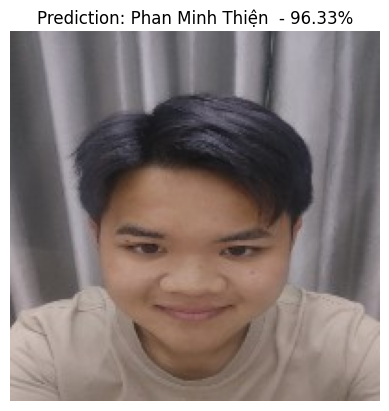

Tiên đoán: Phan Minh Thiện 
Độ tin cậy: 96.33%


In [ ]:
#Upload ảnh để prediction
model = load_model(MODEL_PATH)

with open(LABELS_PATH, "r", encoding="utf-8") as f:
    index_to_class = json.load(f)

def predict_face(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0]

    best_index = np.argmax(prediction)
    confidence = prediction[best_index]
    predicted_name = index_to_class[str(best_index)]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_name} - {confidence*100:.2f}%")
    plt.show()

    print("Tiên đoán:", predicted_name)
    print("Độ tin cậy:", f"{confidence*100:.2f}%")

uploaded = files.upload()

for file_name in uploaded.keys():
    predict_face(file_name)